# Preparing kcEXP00H calcium imaging data for multisession `lfads-torch`

## Objective

This notebook prepares the **kcEXP00H** lightfield microscopy (LFM) calcium imaging dataset for training a multisession LFADS model. The dataset consists of 5 fly recordings, each with ΔF/F traces across 75 annotated brain regions. Because different flies may express different baseline activity levels and response gains, per-fly linear readin matrices are used to map each fly's neural activity into a shared latent dynamical space. These matrices are initialized using **Principal Components Regression (PCR)**, which aligns the condition-averaged ΔF/F responses from each fly to a common set of global principal components.

## Dataset

- **Species / preparation:** adult *Drosophila melanogaster*, LFM whole-brain calcium imaging
- **Data variable:** `deltaF_rg` — ΔF/F traces, shape `(trial, time, region)`
- **Flies:** 5 recordings (`H30003-005`, `H34006-007`, `H35005-006`, `H36006-007`, `H37003-004`)
- **Dimensions per fly:** 18 trials × 1050 timepoints × 75 brain regions
- **Conditions:** defined by combinations of odour, forward-walking, and visual stimuli

> **Key difference from spike-based LFADS:** ΔF/F is already a continuous signal — no Gaussian smoothing is needed. Condition-averaged ΔF/F traces replace PSTHs directly.


## Setup

`%autoreload 2` automatically reloads imported modules on every cell execution, so edits to `Xarray_UtilFns.py` are picked up without restarting the kernel. We also add the `kcAN00H_Python` project to `sys.path` so its utility functions can be imported.


In [36]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '/home/kyc_hpz8/Documents/kcAN00H_Python')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Step 1 – Load xarray datasets

`load_group_xarrays` reads every `.nc` file in `XARRAY_DIR`, attaches within-trial stimulus-onset frame indices to each dataset's attributes, and assigns a `fly_id` from the filename stem. The printed summary shows each fly's trial count and unique condition labels.


In [37]:
import numpy as np
from utils.Xarray_UtilFns import load_group_xarrays, get_condition_mean

XARRAY_DIR = (
    '/media/server/gklab/KarenCheng/DATA/LFM_current/'
    'kcEXP00H/kcEXP00H_PythonNotebooks/xarray_files/'
)

ds_list = load_group_xarrays(XARRAY_DIR)

  H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

Loaded 5 datasets from /media/server/gklab/KarenCheng/DATA/LFM_current/kcEXP00H/kcEXP00H_PythonNotebooks/xarray_files/


## Step 2 – Inspect conditions and find shared conditions

Multisession PCR requires the same set of conditions to be present in every fly so that the concatenated condition-mean matrix is rectangular. We take the **intersection** of conditions across all flies. Any condition absent from even one fly is excluded — this is printed below so you can check for unexpected gaps.


In [38]:
flies = [ds.attrs['fly_id'] for ds in ds_list]

all_cond_sets = []
for ds in ds_list:
    fly_conds = sorted(np.unique(ds.condition.values).tolist())
    print(f"  {ds.attrs['fly_id']:40s}  conditions: {fly_conds}")
    all_cond_sets.append(set(fly_conds))

shared_conds = sorted(set.intersection(*all_cond_sets))
print(f"\nShared conditions ({len(shared_conds)} total): {shared_conds}")

# Report any conditions missing from individual flies
for ds in ds_list:
    fly_conds = set(np.unique(ds.condition.values).tolist())
    missing = set(shared_conds) - fly_conds  # will be empty if intersection is used
    extra   = fly_conds - set(shared_conds)
    if extra:
        print(f"  {ds.attrs['fly_id']}: {len(extra)} condition(s) excluded — {sorted(extra)}")

  H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP  conditions: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP  conditions: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP  conditions: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP  conditions: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP  conditions: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

Shared conditions (8 total): ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']


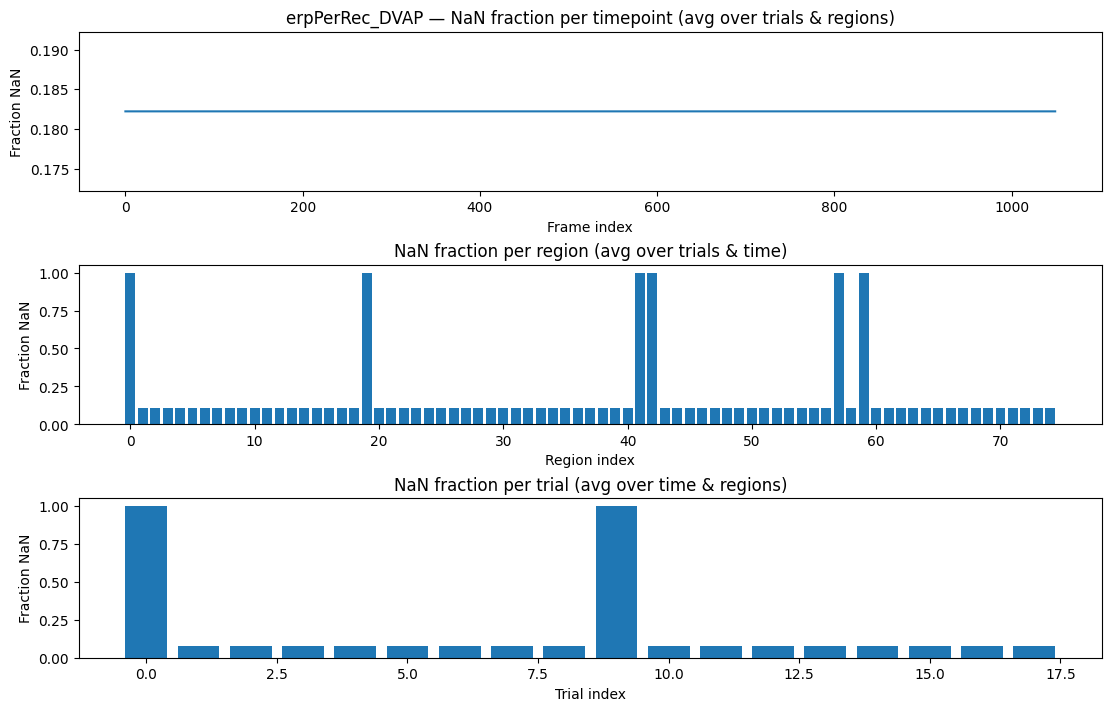

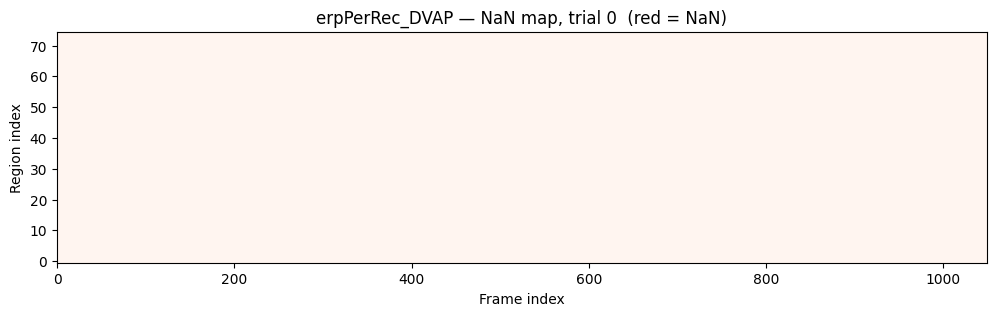

Array shape            : (18, 1050, 75)  (trials, time, regions)
Overall NaN fraction   : 0.182
Frames with any NaN    : 1050 / 1050
Regions with any NaN   : 75 / 75
Trials with any NaN    : 18 / 18
Last frame with any NaN: 1049


In [39]:
# ── Diagnostic: examine NaN structure before any filtering ───────────────
import matplotlib.pyplot as plt

ds0   = ds_list[0]
arr0  = ds0['deltaF_rg'].values          # (18, 1050, 75)
label = ds0.attrs['fly_id'][-14:]

nan_by_time   = np.isnan(arr0).mean(axis=(0, 2))   # (1050,) — avg over trials & regions
nan_by_region = np.isnan(arr0).mean(axis=(0, 1))   # (75,)   — avg over trials & time
nan_by_trial  = np.isnan(arr0).mean(axis=(1, 2))   # (18,)   — avg over time & regions

fig, axes = plt.subplots(3, 1, figsize=(11, 7), constrained_layout=True)

axes[0].plot(nan_by_time)
axes[0].set_xlabel('Frame index'); axes[0].set_ylabel('Fraction NaN')
axes[0].set_title(f'{label} — NaN fraction per timepoint (avg over trials & regions)')

axes[1].bar(range(len(nan_by_region)), nan_by_region)
axes[1].set_xlabel('Region index'); axes[1].set_ylabel('Fraction NaN')
axes[1].set_title('NaN fraction per region (avg over trials & time)')

axes[2].bar(range(len(nan_by_trial)), nan_by_trial)
axes[2].set_xlabel('Trial index'); axes[2].set_ylabel('Fraction NaN')
axes[2].set_title('NaN fraction per trial (avg over time & regions)')
plt.show()

# 2-D NaN map: time × region for a single trial
fig2, ax = plt.subplots(figsize=(12, 3))
ax.imshow(np.isnan(arr0[0]).T, aspect='auto', origin='lower',
          cmap='Reds', interpolation='none')
ax.set_xlabel('Frame index'); ax.set_ylabel('Region index')
ax.set_title(f'{label} — NaN map, trial 0  (red = NaN)')
plt.show()

print(f"Array shape            : {arr0.shape}  (trials, time, regions)")
print(f"Overall NaN fraction   : {np.isnan(arr0).mean():.3f}")
print(f"Frames with any NaN    : {np.isnan(arr0).any(axis=(0,2)).sum()} / {arr0.shape[1]}")
print(f"Regions with any NaN   : {np.isnan(arr0).any(axis=(0,1)).sum()} / {arr0.shape[2]}")
print(f"Trials with any NaN    : {np.isnan(arr0).any(axis=(1,2)).sum()} / {arr0.shape[0]}")
# Find the last frame that contains any NaN
last_nan_frame = int(np.where(np.isnan(arr0).any(axis=(0,2)))[0].max()) if np.isnan(arr0).any() else -1
print(f"Last frame with any NaN: {last_nan_frame}")

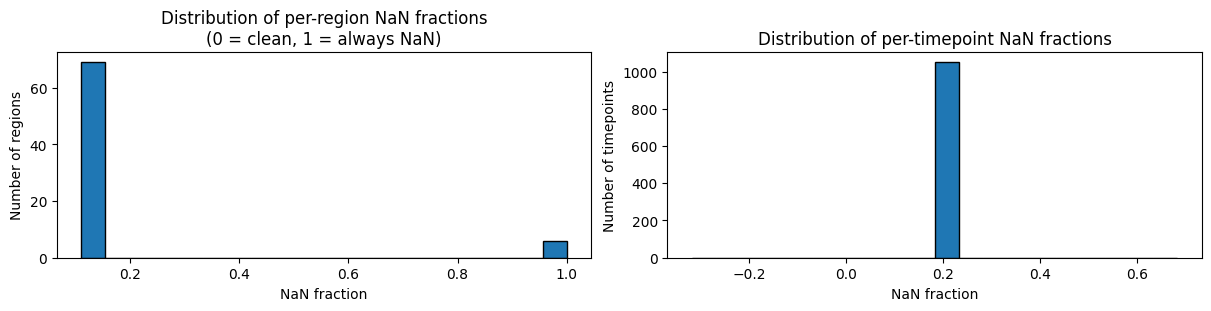

Regions always  NaN (frac=1.0): 6
Regions never   NaN (frac=0.0): 0
Regions partial NaN           : 69

Odor onset frame: 451  →  window [426 : 601]
NaN fraction in odor window    : 0.182
Regions with any NaN in window : 75 / 75


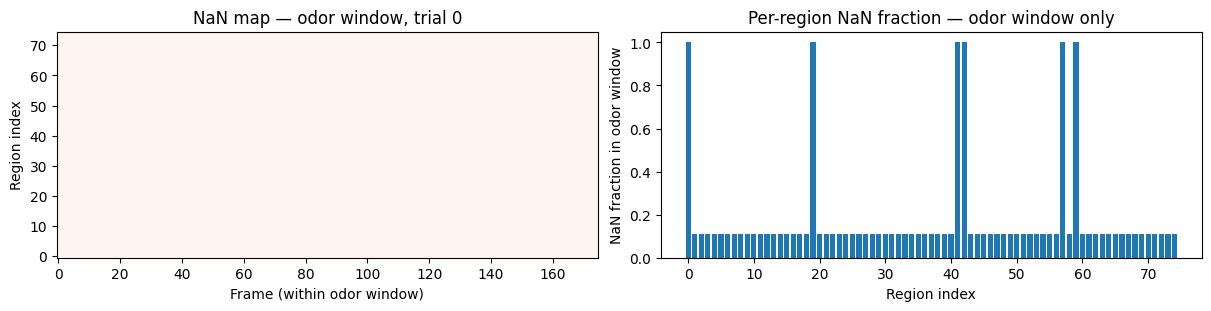

In [40]:
# ── Diagnostic 2: understand the NaN pattern in more detail ──────────────

# Per-region: fraction of (trial × time) that is NaN
nan_frac_per_region = np.isnan(arr0).mean(axis=(0, 1))   # (75,)

# Per-timepoint: fraction of (trial × region) that is NaN
nan_frac_per_time   = np.isnan(arr0).mean(axis=(0, 2))   # (1050,)

fig, axes = plt.subplots(1, 2, figsize=(12, 3), constrained_layout=True)

axes[0].hist(nan_frac_per_region, bins=20, edgecolor='k')
axes[0].set_xlabel('NaN fraction'); axes[0].set_ylabel('Number of regions')
axes[0].set_title('Distribution of per-region NaN fractions\n(0 = clean, 1 = always NaN)')

axes[1].hist(nan_frac_per_time, bins=20, edgecolor='k')
axes[1].set_xlabel('NaN fraction'); axes[1].set_ylabel('Number of timepoints')
axes[1].set_title('Distribution of per-timepoint NaN fractions')
plt.show()

# How many regions are ALWAYS NaN vs. only sometimes?
always_nan  = (nan_frac_per_region == 1.0).sum()
never_nan   = (nan_frac_per_region == 0.0).sum()
partial_nan = 75 - always_nan - never_nan
print(f"Regions always  NaN (frac=1.0): {always_nan}")
print(f"Regions never   NaN (frac=0.0): {never_nan}")
print(f"Regions partial NaN           : {partial_nan}")

# Show NaN map for the odor window specifically
odor_onset = int(np.median(ds0.attrs['odor_framestarts_within_trial']))
win = slice(odor_onset - 25, odor_onset + 150)
print(f"\nOdor onset frame: {odor_onset}  →  window [{odor_onset-25} : {odor_onset+150}]")

nan_in_window = np.isnan(arr0[:, win, :])
print(f"NaN fraction in odor window    : {nan_in_window.mean():.3f}")
print(f"Regions with any NaN in window : {nan_in_window.any(axis=(0,1)).sum()} / 75")

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 3), constrained_layout=True)
axes2[0].imshow(np.isnan(arr0[0, win, :]).T, aspect='auto', origin='lower',
                cmap='Reds', interpolation='none')
axes2[0].set_xlabel('Frame (within odor window)'); axes2[0].set_ylabel('Region index')
axes2[0].set_title('NaN map — odor window, trial 0')

# Average NaN fraction per region within the odor window
nan_in_win_per_region = nan_in_window.mean(axis=(0, 1))
axes2[1].bar(range(75), nan_in_win_per_region)
axes2[1].set_xlabel('Region index'); axes2[1].set_ylabel('NaN fraction in odor window')
axes2[1].set_title('Per-region NaN fraction — odor window only')
plt.show()

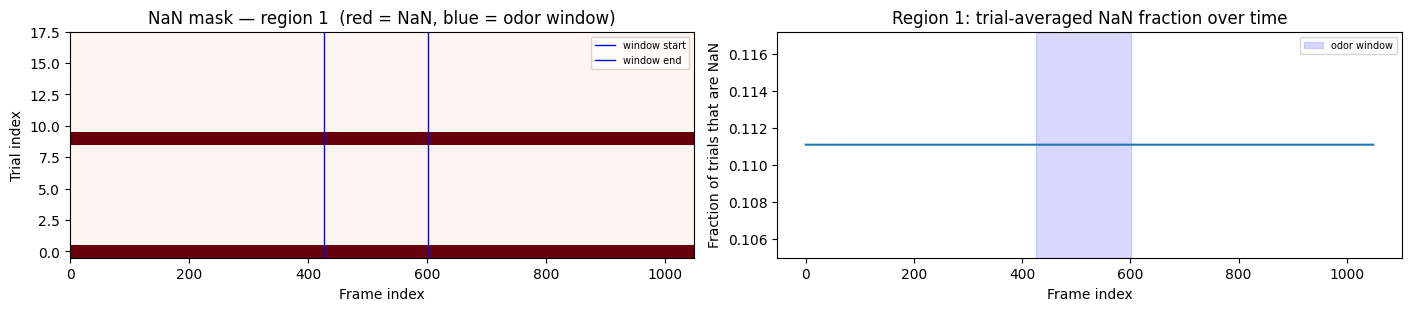

Per-region NaN fraction in odor window:
  region   0: 1.000
  region   1: 0.111
  region   2: 0.111
  region   3: 0.111
  region   4: 0.111
  region   5: 0.111
  region   6: 0.111
  region   7: 0.111
  region   8: 0.111
  region   9: 0.111
  region  10: 0.111
  region  11: 0.111
  region  12: 0.111
  region  13: 0.111
  region  14: 0.111
  region  15: 0.111
  region  16: 0.111
  region  17: 0.111
  region  18: 0.111
  region  19: 1.000
  region  20: 0.111
  region  21: 0.111
  region  22: 0.111
  region  23: 0.111
  region  24: 0.111
  region  25: 0.111
  region  26: 0.111
  region  27: 0.111
  region  28: 0.111
  region  29: 0.111
  region  30: 0.111
  region  31: 0.111
  region  32: 0.111
  region  33: 0.111
  region  34: 0.111
  region  35: 0.111
  region  36: 0.111
  region  37: 0.111
  region  38: 0.111
  region  39: 0.111
  region  40: 0.111
  region  41: 1.000
  region  42: 1.000
  region  43: 0.111
  region  44: 0.111
  region  45: 0.111
  region  46: 0.111
  region  47: 0.111


In [41]:
# ── Diagnostic 3: are NaNs at the same timepoints across trials? ─────────
# Pick one partial-NaN region and plot its NaN mask across all trials
partial_region_idx = np.where((nan_frac_per_region > 0) & (nan_frac_per_region < 1))[0][0]
nan_mask_one_region = np.isnan(arr0[:, :, partial_region_idx])  # (18, 1050)

fig, axes = plt.subplots(1, 2, figsize=(14, 3), constrained_layout=True)

axes[0].imshow(nan_mask_one_region, aspect='auto', origin='lower',
               cmap='Reds', interpolation='none')
axes[0].axvline(odor_onset - 25,  color='blue', linewidth=1, label='window start')
axes[0].axvline(odor_onset + 150, color='blue', linewidth=1, label='window end')
axes[0].set_xlabel('Frame index'); axes[0].set_ylabel('Trial index')
axes[0].set_title(f'NaN mask — region {partial_region_idx}  (red = NaN, blue = odor window)')
axes[0].legend(fontsize=7)

# Fraction of trials that are NaN at each timepoint (for this region)
axes[1].plot(nan_mask_one_region.mean(axis=0))
axes[1].axvspan(odor_onset - 25, odor_onset + 150, alpha=0.15, color='blue', label='odor window')
axes[1].set_xlabel('Frame index'); axes[1].set_ylabel('Fraction of trials that are NaN')
axes[1].set_title(f'Region {partial_region_idx}: trial-averaged NaN fraction over time')
axes[1].legend(fontsize=7)
plt.show()

# Summary: within the odor window, how many (trial, timepoint) pairs are NaN per region?
nan_in_win_per_region_detail = np.isnan(arr0[:, win, :]).mean(axis=(0, 1))  # (75,)
print("Per-region NaN fraction in odor window:")
for i, f in enumerate(nan_in_win_per_region_detail):
    if f > 0:
        print(f"  region {i:3d}: {f:.3f}")

## Step 3 – Handle missing values

Diagnostics show two types of NaN:
1. **6 regions are always NaN** (dead channels) — dropped entirely.
2. **69 regions have scattered NaNs** (~18% of frames) — these are filled by linear interpolation along the time axis per trial, preserving the signal shape where data exists.

All 18 trials are kept.


In [42]:
def fill_nan_trials(arr):
    """
    For each (trial, region) pair where the entire time axis is NaN,
    fill with the mean of that region across valid (non-NaN) trials.
    Falls back to 0 if no valid trials exist for that region.
    """
    out = arr.copy()
    n_trials, n_time, n_regions = out.shape
    for reg in range(n_regions):
        for tri in range(n_trials):
            if np.isnan(out[tri, :, reg]).all():
                # Find other trials that have valid data for this region
                valid_trials = [t for t in range(n_trials)
                                if not np.isnan(out[t, :, reg]).all()]
                if valid_trials:
                    out[tri, :, reg] = np.nanmean(out[valid_trials, :, reg], axis=0)
                else:
                    out[tri, :, reg] = 0.0
    return out

raw_traces    = {}
raw_conds     = {}
valid_regions = {}   # boolean mask (75,) — reused in Step 5

for ds in ds_list:
    fly_id = ds.attrs['fly_id']
    arr  = ds['deltaF_rg'].values    # (18, 1050, 75)
    cond = ds.condition.values

    # 1. Drop regions that are always NaN across ALL trials and ALL timepoints
    always_nan_mask = np.isnan(arr).all(axis=(0, 1))
    keep_mask       = ~always_nan_mask
    arr_clean       = arr[:, :, keep_mask]
    n_dropped = int(always_nan_mask.sum())

    # 2. Fill trials that are entirely NaN for a region with the region's trial mean
    arr_filled = fill_nan_trials(arr_clean)

    remaining_nans = int(np.isnan(arr_filled).sum())
    n_filled_trials = int(np.isnan(arr_clean).all(axis=1).sum())  # (trial, region) pairs imputed
    print(f"  {ds.attrs['fly_id'][-14:]}: dropped {n_dropped} dead regions, "
          f"kept {int(keep_mask.sum())} | "
          f"imputed {n_filled_trials} NaN-trial/region pairs | "
          f"remaining NaNs: {remaining_nans}")

    raw_traces[fly_id]    = arr_filled
    raw_conds[fly_id]     = cond
    valid_regions[fly_id] = keep_mask

{fly: arr.shape for fly, arr in raw_traces.items()}

  erpPerRec_DVAP: dropped 6 dead regions, kept 69 | imputed 138 NaN-trial/region pairs | remaining NaNs: 0
  erpPerRec_DVAP: dropped 4 dead regions, kept 71 | imputed 142 NaN-trial/region pairs | remaining NaNs: 0
  erpPerRec_DVAP: dropped 4 dead regions, kept 71 | imputed 142 NaN-trial/region pairs | remaining NaNs: 0
  erpPerRec_DVAP: dropped 4 dead regions, kept 71 | imputed 142 NaN-trial/region pairs | remaining NaNs: 0
  erpPerRec_DVAP: dropped 6 dead regions, kept 69 | imputed 138 NaN-trial/region pairs | remaining NaNs: 0


{'H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP': (18, 1050, 69),
 'H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': (18, 1050, 71),
 'H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP': (18, 1050, 71),
 'H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': (18, 1050, 71),
 'H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP': (18, 1050, 69)}

## Step 4 – Crop to a window around odour onset

1050 timepoints per trial is far too long for LFADS (typical targets: 50–200 timepoints). We crop each trial to a fixed window relative to odour onset, using the within-trial frame index stored in `ds.attrs['odor_framestarts_within_trial']`.

**`PRE_FRAMES` and `POST_FRAMES` are the key parameters to adjust** if you want a longer or shorter window, or if you want to centre on a different stimulus.

> At 30 Hz imaging, 1 frame ≈ 33 ms. The defaults below give a **~0.83 s pre- / ~5 s post-onset** window (175 frames total).


In [43]:
# ── Configurable parameters ──────────────────────────────────────────────
PRE_FRAMES  = 25   # frames before odour onset  (~0.83 s at 30 Hz)
POST_FRAMES = 150  # frames after  odour onset  (~5 s at 30 Hz)
# ─────────────────────────────────────────────────────────────────────────

traces = {}   # windowed raw trials — used for HDF5 saving
conds  = {}   # matching condition labels

for ds, fly_id in zip(ds_list, flies):
    # Median onset frame across odour trials (should be constant within an experiment)
    odor_onset_frame = int(np.median(ds.attrs['odor_framestarts_within_trial']))
    window = slice(odor_onset_frame - PRE_FRAMES, odor_onset_frame + POST_FRAMES)

    arr   = raw_traces[fly_id][:, window, :]   # (n_trials, n_window, 75)
    cond  = raw_conds[fly_id]
    traces[fly_id] = arr
    conds[fly_id]  = cond

n_window = PRE_FRAMES + POST_FRAMES
print(f"Window length: {n_window} frames  "
      f"({PRE_FRAMES} pre / {POST_FRAMES} post odour onset)")
{fly: arr.shape for fly, arr in traces.items()}

Window length: 175 frames  (25 pre / 150 post odour onset)


{'H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP': (18, 175, 69),
 'H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': (18, 175, 71),
 'H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP': (18, 175, 71),
 'H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': (18, 175, 71),
 'H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP': (18, 175, 69)}

## Step 5 – Compute condition-averaged ΔF/F (trial averages)

For each fly and each shared condition, we average the windowed ΔF/F across trials using `get_condition_mean`. This produces the equivalent of a PSTH but for calcium imaging: the trial-averaged ΔF/F response profile. The result per fly has shape `(n_shared_conds, n_window, n_regions)`.

Note: `get_condition_mean` operates on the **original unwindowed dataset**; we apply the same time window to the resulting mean trace after averaging.


In [44]:
psths = {}

for ds, fly_id in zip(ds_list, flies):
    odor_onset_frame = int(np.median(ds.attrs['odor_framestarts_within_trial']))
    window = slice(odor_onset_frame - PRE_FRAMES, odor_onset_frame + POST_FRAMES)
    mask   = valid_regions[fly_id]   # same region mask from Step 3

    sess_means = []
    for cond in shared_conds:
        mean_da, n_tr = get_condition_mean(ds, cond)
        sess_means.append(mean_da.values[window, :][:, mask])   # (n_window, n_valid_regions)
    psths[fly_id] = np.array(sess_means)   # (n_conds, n_window, n_valid_regions)

{fly: p.shape for fly, p in psths.items()}

{'H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP': (8, 175, 69),
 'H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': (8, 175, 71),
 'H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP': (8, 175, 71),
 'H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': (8, 175, 71),
 'H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP': (8, 175, 69)}

## Visualize – single trial ΔF/F vs. condition mean

A sanity-check panel for the first shared condition of the first fly. **Left:** one individual trial (ΔF/F heatmap, regions × time). **Right:** the condition mean across all trials for that condition (same axes). Both are windowed around odour onset.


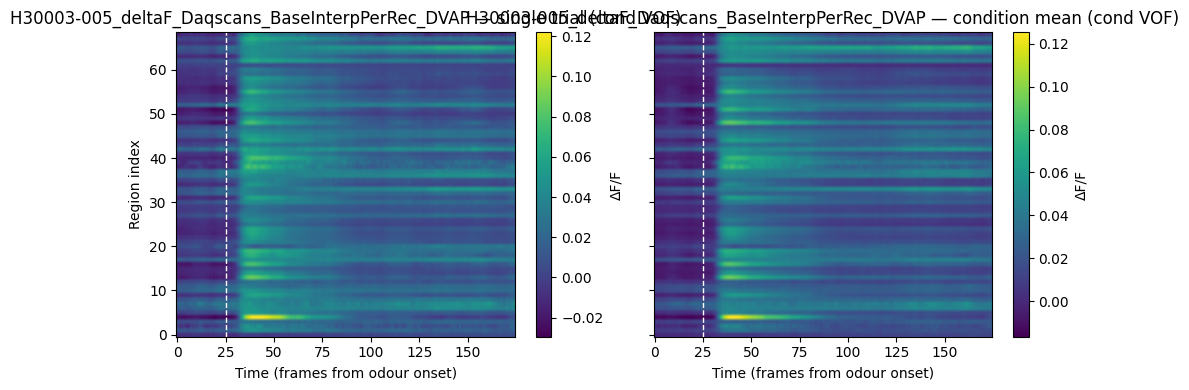

In [45]:
import matplotlib.pyplot as plt

fly_id   = flies[0]
cond_idx = 0   # index into shared_conds

# Find a trial belonging to this condition in the windowed traces
cond_val  = shared_conds[cond_idx]
trial_idx = np.where(conds[fly_id] == cond_val)[0][0]
single_trial = traces[fly_id][trial_idx]   # (n_window, 75)
cond_mean    = psths[fly_id][cond_idx]     # (n_window, 75)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
im1 = ax1.imshow(single_trial.T, aspect='auto', origin='lower')
ax1.axvline(PRE_FRAMES, color='white', linewidth=1, linestyle='--')
ax1.set_title(f'{fly_id} — single trial (cond {cond_val})')
ax1.set_xlabel('Time (frames from odour onset)'); ax1.set_ylabel('Region index')
plt.colorbar(im1, ax=ax1, label='ΔF/F')

im2 = ax2.imshow(cond_mean.T, aspect='auto', origin='lower')
ax2.axvline(PRE_FRAMES, color='white', linewidth=1, linestyle='--')
ax2.set_title(f'{fly_id} — condition mean (cond {cond_val})')
ax2.set_xlabel('Time (frames from odour onset)')
plt.colorbar(im2, ax=ax2, label='ΔF/F')

plt.tight_layout()
plt.show()

## Step 6 – Concatenate all fly condition means for global PCA

We stack the condition means from all 5 flies along the region axis (last axis), then flatten conditions and timepoints into a single row index. The resulting matrix has shape `(n_conds × n_window, total_regions_across_flies)`. This is the input to global PCA — it captures population dynamics pooled across all flies so that a single shared latent space can be found.


In [46]:
sessions = sorted(psths.keys())  # alphabetical fly order

combined_psths = np.concatenate([psths[f] for f in sessions], axis=-1)
combined_psths = combined_psths.reshape(-1, combined_psths.shape[-1])
n_regions_total = sum(psths[f].shape[-1] for f in sessions)
print(f"Combined condition-mean matrix: {combined_psths.shape}")
print(f"  = ({len(shared_conds)} conds × {n_window} timepoints, "
      f"{n_regions_total} total regions across {len(sessions)} flies)")
print(f"  Regions per fly: { {f: psths[f].shape[-1] for f in sessions} }")

Combined condition-mean matrix: (1400, 351)
  = (8 conds × 175 timepoints, 351 total regions across 5 flies)
  Regions per fly: {'H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP': 69, 'H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': 71, 'H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP': 71, 'H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': 71, 'H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP': 69}


## Visualize – concatenated condition-mean heatmap

The heatmap rows are the concatenated (condition × timepoint) axis; columns are the concatenated (fly × region) axis. You should see distinct blocks of activity for each condition, confirming the matrix is correctly shaped before PCA.


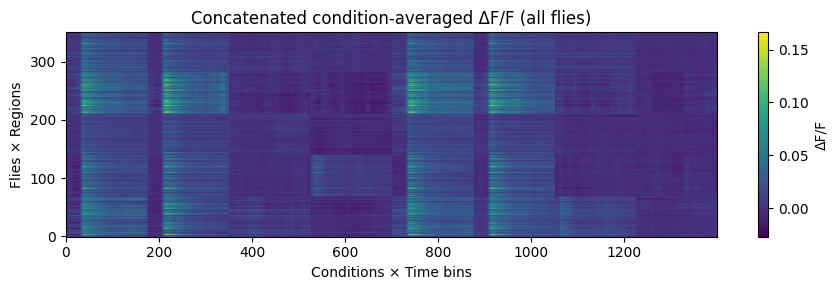

In [47]:
fig, ax = plt.subplots(figsize=(9, 3))
im = ax.imshow(combined_psths.T, aspect='auto', origin='lower')
plt.colorbar(im, label='ΔF/F')
ax.set_xlabel('Conditions × Time bins'); ax.set_ylabel('Flies × Regions')
ax.set_title('Concatenated condition-averaged ΔF/F (all flies)')
plt.tight_layout()
plt.show()

## Step 7 – Global PCA across all flies

We mean-centre the concatenated matrix per region (column) before fitting PCA. Mean-centring removes between-region differences in baseline ΔF/F so that PCA captures response dynamics rather than static offsets. We fit up to 50 components and plot cumulative variance explained to find the number of PCs needed to capture ≥90% of variance. The resulting PC space is the **shared latent space** that all flies will be aligned into via PCR.


2 PCs needed to explain 90% of variance.


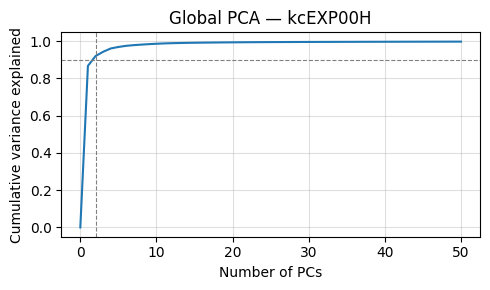

In [48]:
from sklearn.decomposition import PCA

n_components = 50
combined_psths_ctrd = combined_psths - np.mean(combined_psths, axis=0)
pca = PCA(n_components).fit(combined_psths_ctrd)
combined_psth_pcs = pca.transform(combined_psths_ctrd)

cumvar_expl = np.concatenate([[0], np.cumsum(pca.explained_variance_ratio_)])
n_pcs_90 = int(np.where(cumvar_expl > 0.9)[0][0])
print(f"{n_pcs_90} PCs needed to explain 90% of variance.")

plt.figure(figsize=(5, 3))
plt.plot(cumvar_expl)
plt.axhline(0.9, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(n_pcs_90, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.4)
plt.xlabel('Number of PCs'); plt.ylabel('Cumulative variance explained')
plt.title('Global PCA — kcEXP00H')
plt.tight_layout()
plt.show()

## Visualize – Global PC trajectories colored by condition

We reshape the global PC scores back to `(n_conds, n_window, n_components)` and plot the first 3 PCs as 3D time-series trajectories. Each condition gets a distinct color. If the global PCs have captured meaningful stimulus-driven structure, you should see the trajectories separate by condition.


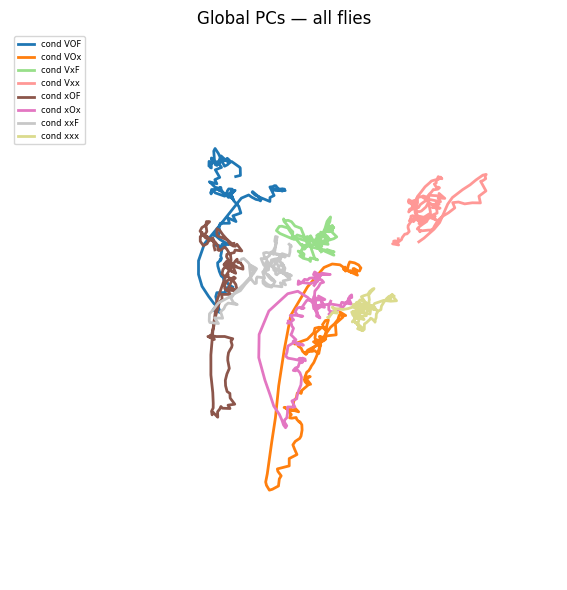

In [49]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

n_conds_shared = len(shared_conds)
psth_pcs = combined_psth_pcs.reshape(n_conds_shared, n_window, n_components)

fig = plt.figure(figsize=(6, 6))
ax  = fig.add_subplot(projection='3d')
for i, cond_val in enumerate(shared_conds):
    color = cm.tab20(i / max(n_conds_shared, 1))
    ax.plot(*psth_pcs[i].T[:3], color=color, linewidth=2, label=f'cond {cond_val}')
ax.view_init(elev=30, azim=30)
ax.set_title('Global PCs — all flies')
ax.axis('off')
if n_conds_shared <= 12:
    ax.legend(fontsize=6, loc='upper left')
plt.tight_layout()
plt.show()

## Step 8 – Per-fly Principal Components Regression (PCR)

For each fly, we fit a Ridge regression model that maps that fly's mean-centred condition-averaged ΔF/F to the **global PC scores** from Step 7. This gives:

- `weights[fly_id]` — shape `(n_valid_regions, 50)`: the *readin matrix* projecting this fly's ΔF/F into the shared PC space (n_valid_regions is 69 or 71 depending on fly)
- `biases[fly_id]` — shape `(n_valid_regions,)`: the per-region mean used to centre the data at inference time

These weights are saved as the PCR initialization for lfads-torch's per-fly readin layers, ensuring all flies start training aligned in the same latent space.


In [50]:
from sklearn.linear_model import Ridge

latents = {}
weights = {}
biases  = {}

n_conds_shared = len(shared_conds)

for fly_id in sessions:
    data = psths[fly_id].reshape(-1, psths[fly_id].shape[-1])   # (n_conds*n_window, 75)
    data_means = data.mean(axis=0)                               # (75,)
    data_ctrd  = data - data_means

    model = Ridge(alpha=1.0, fit_intercept=False, random_state=42)
    model.fit(data_ctrd, combined_psth_pcs)

    latents[fly_id] = model.predict(data_ctrd).reshape(
        (n_conds_shared, n_window, n_components))
    weights[fly_id] = model.coef_.T   # (75, n_components)
    biases[fly_id]  = data_means      # (75,)

{fly: w.shape for fly, w in weights.items()}

{'H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP': (69, 50),
 'H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': (71, 50),
 'H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP': (71, 50),
 'H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': (71, 50),
 'H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP': (69, 50)}

## Visualize – Per-fly PC trajectories

Each fly's locally aligned PC space (via PCR) is plotted in its own 3D panel. If PCR worked correctly, the trajectory shapes should look similar across all 5 flies — same condition structure, similar separations.


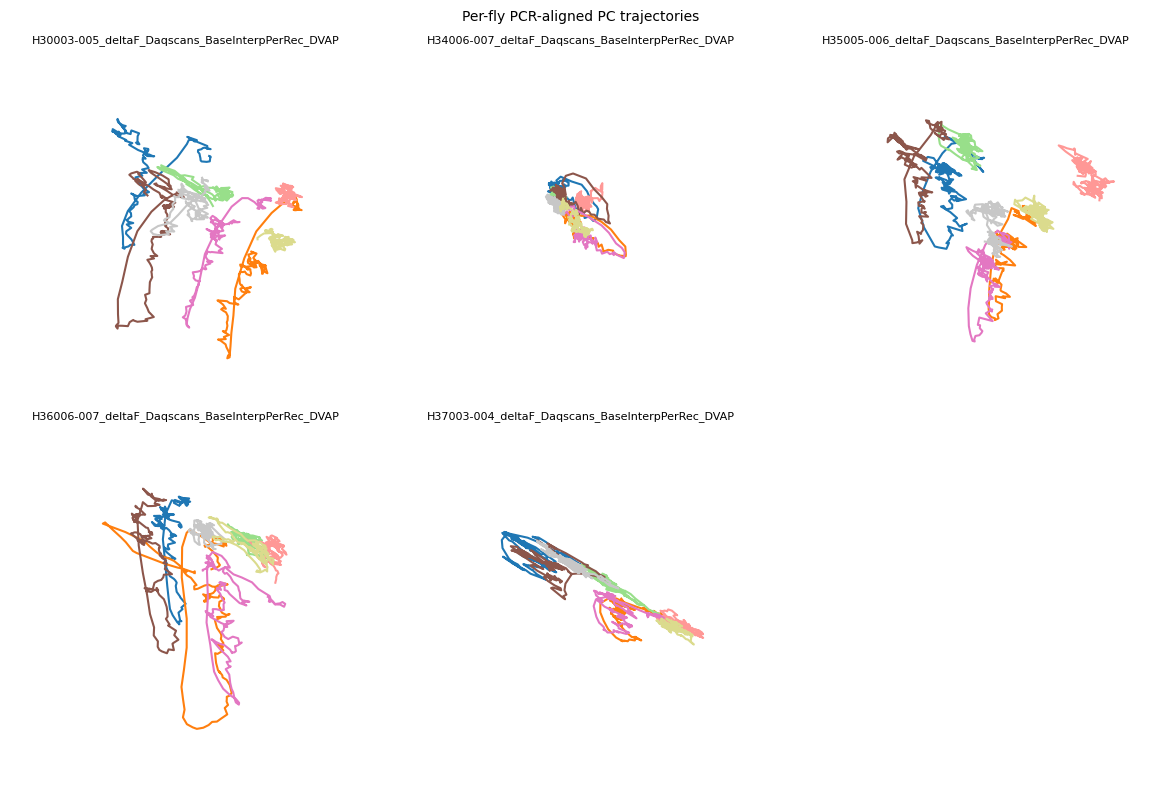

In [51]:
fig = plt.figure(figsize=(12, 8))
nrows, ncols = 2, 3

for i, fly_id in enumerate(sessions):
    ax = fig.add_subplot(nrows, ncols, i + 1, projection='3d')
    for j, cond_val in enumerate(shared_conds):
        color = cm.tab20(j / max(n_conds_shared, 1))
        ax.plot(*latents[fly_id][j].T[:3], color=color, linewidth=1.5)
    ax.view_init(elev=30, azim=30)
    ax.axis('off')
    ax.set_title(fly_id, fontsize=8)

# Leave last subplot blank if only 5 flies
if len(sessions) < nrows * ncols:
    fig.add_subplot(nrows, ncols, nrows * ncols).axis('off')

plt.suptitle('Per-fly PCR-aligned PC trajectories', fontsize=10)
plt.tight_layout()
plt.show()

## Diagnostic – Compare response magnitudes across flies

Plot the grand-mean ΔF/F (averaged over all regions) per condition and per fly. If two flies have weaker responses overall, their lines will sit closer to zero — which would explain why their PC trajectories are compact.

### Should ΔF/F be z-scored before PCR?

**Yes — z-score per region, per fly**, computed over the condition-mean matrix before PCA.

Without z-scoring, high-amplitude flies dominate the global PCA: the first PC captures overall response size rather than condition structure, and low-amplitude flies get projected into a small corner of the latent space (the compact trajectories you saw). Z-scoring each region to unit variance makes the PCA focus on *response shape* and *condition separation* rather than amplitude, giving all flies equal weight.

**Where to apply it:**
- On `psths[fly_id]` before Step 6 (PCA / PCR) — so the PCR weights are learned from normalised dynamics
- On `traces[fly_id]` before Step 9 (HDF5 saving) — so LFADS trains on normalised data; the Gaussian reconstruction loss then models residual variance directly

The z-score is computed per region over the flattened `(n_conds × n_window)` axis of the condition-mean matrix, then applied to the raw trial traces using the same per-region mean and std.


Peak |mean ΔF/F| per fly (max over conditions and time):
  erpPerRec_DVAP   0.0574
  erpPerRec_DVAP   0.0469
  erpPerRec_DVAP   0.0233
  erpPerRec_DVAP   0.0747
  erpPerRec_DVAP   0.0350


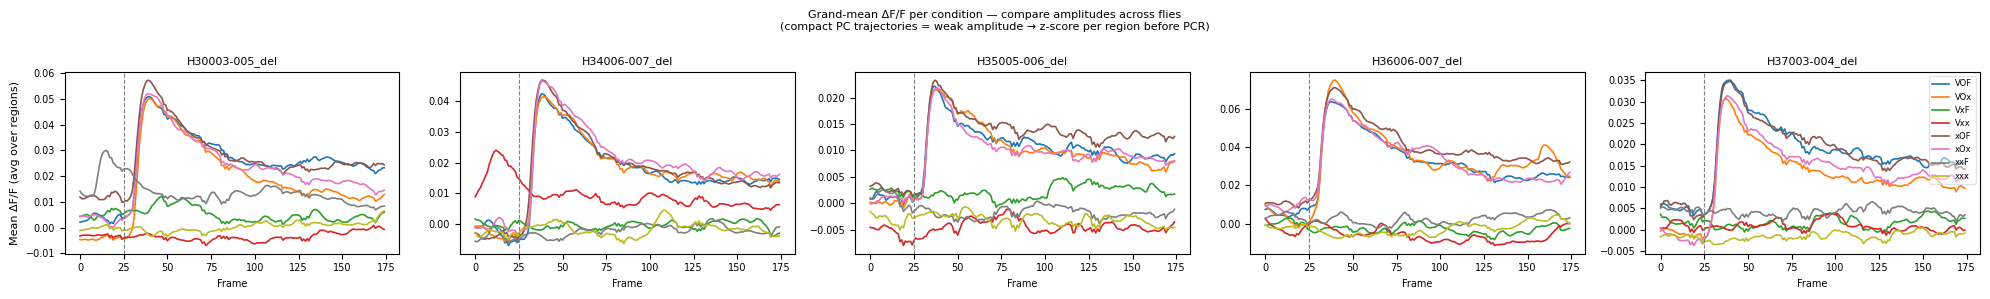

In [52]:
# Grand-mean ΔF/F per condition — compare response magnitudes across flies
# psths[fly_id] shape: (n_conds, n_window, n_regions)
# .mean(axis=2) averages over regions → (n_conds, n_window)

import matplotlib.cm as cm

fig, axes = plt.subplots(1, len(sessions), figsize=(4 * len(sessions), 3), sharey=False)
if len(sessions) == 1:
    axes = [axes]

for i, fly_id in enumerate(sessions):
    grand_mean = psths[fly_id].mean(axis=2)   # (n_conds, n_window)
    for j, cond_val in enumerate(shared_conds):
        color = cm.tab10(j / len(shared_conds))
        axes[i].plot(grand_mean[j], color=color, linewidth=1.2, label=cond_val)
    axes[i].axvline(PRE_FRAMES, color='gray', linestyle='--', linewidth=0.8)
    axes[i].set_title(fly_id.split('/')[-1][:14], fontsize=8)
    axes[i].set_xlabel('Frame', fontsize=7)
    axes[i].tick_params(labelsize=7)

axes[0].set_ylabel('Mean ΔF/F (avg over regions)', fontsize=8)
axes[-1].legend(fontsize=6, loc='upper right', framealpha=0.5)

# Print peak absolute amplitude per fly to quantify differences
print("Peak |mean ΔF/F| per fly (max over conditions and time):")
for fly_id in sessions:
    peak = float(np.abs(psths[fly_id].mean(axis=2)).max())
    print(f"  {fly_id[-14:]:15s}  {peak:.4f}")

plt.suptitle('Grand-mean ΔF/F per condition — compare amplitudes across flies\n'
             '(compact PC trajectories = weak amplitude → z-score per region before PCR)',
             fontsize=8)
plt.tight_layout()
plt.show()


## Step 9 – Save HDF5 files for `lfads-torch`

Each fly is saved to its own `.h5` file. Trials are split 80/20: every 5th trial (index % 5 == 0) goes to the **validation** set; the rest to **training**. Because 18 trials is a small dataset, this gives approximately 14 training and 4 validation trials per fly.

Both `encod_data` (encoder input) and `recon_data` (reconstruction target) contain the same windowed ΔF/F array — standard LFADS practice when there is no held-out neuron set. The PCR `readin_weight` and `readout_bias` are stored alongside so that lfads-torch can initialize its per-fly readin matrices directly from these files.

**Output:** `../../datasets/kcEXP00H_multisession/lfads_{fly_id}.h5`


In [53]:
import os
import h5py

data_dir = "../../datasets/kcEXP00H_multisession"
os.makedirs(data_dir, exist_ok=True)

for fly_id in sessions:
    fly_traces = traces[fly_id]   # (n_trials, n_window, 75)
    n_trials   = len(fly_traces)

    train_inds, valid_inds = [], []
    for i in range(n_trials):
        if (i % 5) == 0:
            valid_inds.append(i)
        else:
            train_inds.append(i)
    train_inds = np.array(train_inds)
    valid_inds = np.array(valid_inds)

    print(f"  {fly_id}: {len(train_inds)} train / {len(valid_inds)} valid trials")

    kwargs = dict(dtype='float32', compression='gzip')
    with h5py.File(f"{data_dir}/lfads_{fly_id}.h5", 'w') as h5f:
        h5f.create_dataset('train_encod_data', data=fly_traces[train_inds], **kwargs)
        h5f.create_dataset('valid_encod_data', data=fly_traces[valid_inds], **kwargs)
        h5f.create_dataset('train_recon_data', data=fly_traces[train_inds], **kwargs)
        h5f.create_dataset('valid_recon_data', data=fly_traces[valid_inds], **kwargs)
        h5f.create_dataset('train_inds',       data=train_inds,             **kwargs)
        h5f.create_dataset('valid_inds',       data=valid_inds,             **kwargs)
        h5f.create_dataset('readin_weight',    data=weights[fly_id],        **kwargs)
        h5f.create_dataset('readout_bias',     data=biases[fly_id],         **kwargs)

print(f"\nSaved {len(sessions)} .h5 files to {data_dir}/")

  H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP: 14 train / 4 valid trials
  H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: 14 train / 4 valid trials
  H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP: 14 train / 4 valid trials
  H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: 14 train / 4 valid trials
  H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP: 14 train / 4 valid trials

Saved 5 .h5 files to ../../datasets/kcEXP00H_multisession/


## Training `lfads-torch`

Now that the HDF5 files are prepared with PCR initialization weights, the next steps are:

1. Ensure `lfads-torch` is installed (see the [repository README](https://github.com/arsedler9/lfads-torch)).
2. Create a **datamodule config** pointing to `../../datasets/kcEXP00H_multisession/` — use `configs/datamodule/rouse_multisession_PCR.yaml` as a template, updating the `data_dir` and `n_neurons` (75 regions per fly).
3. Create a **model config** — use `configs/model/rouse_multisession_PCR.yaml` as a template. Key parameters to set:
   - `encod_data_dim`: 75 (number of regions)
   - `co_dim` / `ic_dim` / `fac_dim`: adjust based on the number of PCs needed (see Step 7 output)
4. Run training via `scripts/run_pbt.py`.

> **Note on trial count:** With only 18 trials per fly, LFADS will have very limited data. Consider whether pooling all fly data into a single large session (if flies share the same 75 regions) might be more appropriate, or whether the per-fly readin layers are needed to capture fly-to-fly response variability.
